In [1]:
import pandas as pd
import psycopg2
from scholarly import scholarly
import re 
from multiprocessing import Pool
from functools import partial
from tqdm import tqdm 
import networkx as nx
import matplotlib.pyplot as plt
import glob

main_path = "/home/fs01/spec1142/Emma/GateKeepers/validation/"

f = open('/home/fs01/spec1142/Emma/GateKeepers/' + "database.txt", "r")
user , password = f.read().split()



In [10]:
## load SI file 

df = pd.read_csv("/home/fs01/spec1142/Emma/GateKeepers/" + "gatekeepers_intermediate_clean_v5.tsv", delimiter = '\t' )


,inventor_id,author_id,number of comparison,number of match,author_name,inventor_name,name score,flag,number of papers,number of patents
1256622,fl:ti_ln:goldburt-1,A5015301216,272,50,tim goldburt,tim goldburt,0.662193,0,16.0,18.0
307697,fl:al_ln:bogdanov-4,A5005593542,2,1,a a bogdanov,alexander a bogdanov,0.570843,0,3.0,1.0
11191,fl:ad_ln:henke-1,A5023666180,21,9,adam henke,adam henke,0.587251,0,23.0,1.0
978859,fl:xi_ln:zhong-84,A5088003858,6,6,xiaofeng zhong,xiaofeng zhong,0.524828,0,6.0,1.0
1194245,fl:yu_ln:kitade-4,A5090989452,3,1,yuya kitade,yuya kitade,0.608474,0,5.0,1.0


In [22]:
df['confidence_score'] = round(100*df['number of match'] / df['number of comparison'],2)

In [39]:
df[['inventor_id', 'author_id','author_name', 'inventor_name', 'number of papers', 'number of patents',
        'confidence_score']].sample(n=5)

,inventor_id,author_id,author_name,inventor_name,number of papers,number of patents,confidence_score
123504,fl:hu_ln:zhang-157,A5043244896,huan huan zhang,huan huan zhang,10.0,25.0,5.33
1065392,fl:we_ln:wirges-1,A5004523370,werner wirges,werner wirges,142.0,1.0,99.26
286106,fl:hi_ln:ochiai-2,A5030536998,hirotoshi ochiai,hirotoshi ochiai,4.0,1.0,100.00
783921,fl:mi_ln:vanier-1,A5077014627,michael vanier,michael christopher vanier,10.0,1.0,77.78
621768,fl:do_ln:griffin-16,A5074384510,donald j griffin,donald j griffin,3.0,3.0,33.33


In [37]:
#df = df[df['number of match'] / df['number of comparison'] > 0.5]

## Manual validation with Google Scholar

In [373]:
## enter the name of a SI Berkeley faculty 
name = 'Stuart Russell'

### Get Google Scholar profiles

In [374]:
## try to find the SI in Google Scholar

# Retrieve the author's data, fill-in, and print
# Get an iterator for the author results
search_query = scholarly.search_author(name)


In [375]:
## check if the Google Scholar profile corresponds. Otherwise, re-run the cell to generate another profile. 

author_result = next(search_query)
author_result

{'container_type': 'Author',
 'filled': [],
 'source': <AuthorSource.SEARCH_AUTHOR_SNIPPETS: 'SEARCH_AUTHOR_SNIPPETS'>,
 'scholar_id': '2oy3OXYAAAAJ',
 'url_picture': 'https://scholar.google.com/citations?view_op=medium_photo&user=2oy3OXYAAAAJ',
 'name': 'Stuart Russell',
 'affiliation': 'Professor of Computer Science, University of California, Berkeley',
 'email_domain': '@cs.berkeley.edu',
 'interests': ['Artificial Intelligence'],
 'citedby': 113738}

In [376]:
## get the profile's publication's titles. 

author = scholarly.fill(author_result )


### Get OA / PV papers and patents

In [377]:
## find the SI in the SI file

name = 'Stuart Russell'
name_db = name.lower()
df[ ( df['inventor_name'].str.contains(name_db)) ]

,inventor_id,author_id,number of comparison,number of match,author_name,inventor_name,name score,flag,number of patents,number of papers
14137,fl:st_ln:maudsley-1,A5033862949,370,178,stuart maudsley,stuart russell maudsley,0.682872,0,2.0,197.0
14138,fl:st_ln:maudsley-1,A5002981379,6,2,stuart maudsley,stuart russell maudsley,0.682872,0,2.0,4.0
353581,fl:st_ln:russell-35,A5007305440,1212,23,stuart russell,stuart russell,0.528608,0,4.0,345.0
353582,fl:st_ln:russell-34,A5007305440,6666,187,stuart russell,stuart russell,0.528608,0,22.0,345.0
353583,fl:st_ln:russell-34,A5054034179,8998,333,stuart d russell,stuart russell,0.528608,0,22.0,495.0
701002,fl:da_ln:russell-1,A5039687375,81,35,damon russell,damon stuart russell,0.513120,0,3.0,40.0


In [4]:
## get author_id / inventor_id of the SI 

author_id = 'A5054034179'
inventor_id = 'fl:st_ln:russell-34'

In [5]:
## get all paper's title corresponding to the author id from OpenAlex

#establishing the connection
conn = psycopg2.connect("user=" + user + " password=" + password )

#Creating a cursor object using the cursor() method
cursor = conn.cursor()

text = """select  w.title
          from works_OpenAlex as w
          join works_authors_OpenAlex as wa on w.work_id = wa.work_id
          where wa.author_id = '""" + author_id + """'
          order by title
          ;"""

cursor.execute(text)
res1 = cursor.fetchall()

In [402]:
## get all patent's title & number corresponding to the inventor id from PatentsView


#establishing the connection
conn = psycopg2.connect("user=" + user + " password=" + password )

#Creating a cursor object using the cursor() method
cursor = conn.cursor()

text = """select  p.patent_title , p.patent_id
          from patents_PatentsView as p
          join inventors_PatentsView as i on p.patent_id = i.patent_id
          where i.inventor_id = '""" + inventor_id + """'
          ;"""

cursor.execute(text)
res2 = cursor.fetchall()

### Generate comparison file between OA - GS and PV - GS

In [403]:
## compare google scholar titles with OpenAlex and PatentsView titles

list_titles_google_scholar = []
list_patents_google_scholar = []

for k in range(len(author['publications'])):

    ## if the document is caracterise as "Patent", compare it with PatentsView
    if 'citation' in author['publications'][k]['bib'] and 'Patent' in author['publications'][k]['bib']['citation']:
        list_patents_google_scholar.append( ( re.sub('[^0-9a-zA-Z ]+', ' ', author['publications'][k]['bib']['title'].lower()) , author['publications'][k]['bib']['citation']))
    
    ## else, compare it with OpenAlex
    else:
        list_titles_google_scholar.append(re.sub('[^0-9a-zA-Z ]+', ' ', author['publications'][k]['bib']['title'].lower()))

## sort list of papers and patents
list_titles_google_scholar.sort()
list_patents_google_scholar.sort()

In [404]:
## clean OpenAlex and PatentsView titles 

list_titles_OA = [ re.sub('[^0-9a-zA-Z ]+', ' ', elem[0].lower()) for elem in res1 ] 
list_titles_OA.sort()
list_titles_PV = [ ( re.sub('[^0-9a-zA-Z ]+', ' ', elem[0].lower()) , elem[1] )for elem in res2 ] 
list_titles_PV.sort()

In [405]:
## store Google Scholar papers and OpenAlex papers. Mark as 1 when an exact match is found

df_papers = pd.DataFrame()

found = set(list_titles_google_scholar) & set(list_titles_OA)

df_papers['GoogleScholar'] = list_titles_google_scholar + [None]*(max(len(list_titles_OA) - len(list_titles_google_scholar),0))
df_papers['OpenAlex'] = list_titles_OA + [None]*(max(len(list_titles_google_scholar) - len(list_titles_OA),0))
df_papers['Google Scholar in OpenAlex'] = [ 1 if elem  in found else 'x' if pd.isna(elem) == True else None for elem in df_papers['GoogleScholar'] ] 
df_papers['OpenAlex in Google Scholar'] = [ 1 if elem in found else 'x' if pd.isna(elem) == True else None for elem in df_papers['OpenAlex'] ] 


In [406]:
## store Google Scholar patents and OpenAlex patents. Mark as 1 when an exact match is found

df_patents = pd.DataFrame()

found = set([ elem[0] for elem in list_patents_google_scholar]) & set([ elem[0] for elem in list_titles_PV])

df_patents['GoogleScholar'] = list_patents_google_scholar + [None]*(max(len(list_titles_PV) - len(list_patents_google_scholar),0))
df_patents['Patent application?'] = [ 'x' if pd.isna(elem) == True else 1 if 'App.' in elem[1] else 0 for elem in df_patents['GoogleScholar'] ] 
df_patents['PatentsView'] = list_titles_PV + [None]*(max(len(list_patents_google_scholar) - len(list_titles_PV),0))
df_patents['Google Scholar in PatentsView'] = [ 'x' if pd.isna(elem[0]) == True or elem[1] == 1 else 1 if elem[0][0] in found  else None for elem in df_patents[['GoogleScholar','Patent application?']].to_numpy() ] 
df_patents['PatentsView in GoogleScholar'] = [ 'x' if pd.isna(elem) else 'x' if elem[1] == 1 else 1 if elem[0] in found else None for elem in df_patents['PatentsView'] ] 



In [409]:
## save the files as excel files 

df_patents.to_excel(main_path + "patents_" + inventor_id + "_" + name.lower().replace(' ','_') + ".xlsx")
df_papers.to_excel(main_path + "papers_" + author_id + "_" + name.lower().replace(' ','_') + ".xlsx")

### Analysis of the results

In [140]:
files = glob.glob(main_path + "manual_validation_GoogleScholar/*")

In [149]:
results_PV_in_GC = [] 
results_GC_in_PV = [] 
results_GC_in_OA = []
results_OA_in_GC = []
df_files_PV = [] 
df_files_OA = [] 

for file in files:   
    if "patent" in file:
        df = pd.read_excel(file)
        name = file.split('/')[-1].split('#')[1]
        names = name.split('_')
        name = names[0] + ':' + names[1] + '_' + names[2] + ':' + names[3]

        if 'Google Scholar in PatentsView' in df.columns:
            df_files_PV.append(name)
            results_GC_in_PV.append(len(df[(df["Google Scholar in PatentsView"] == 1) & (df['Patent application?'] == 0)]) / len(df[(df["Google Scholar in PatentsView"] != 'x') & (df['Patent application?'] == 0) & (df["Google Scholar in PatentsView"].notnull())]))
            results_PV_in_GC.append(len(df[ (df["PatentsView in GoogleScholar"] == 1)]) / len(df[ ( df["PatentsView in GoogleScholar"] != 'x') &  (df["PatentsView in GoogleScholar"].notnull())]))    
        else:
            df_files_PV.append(name)
            results_GC_in_PV.append(None)
            results_PV_in_GC.append(len(df[ (df["PatentsView in GoogleScholar"] == 1)]) / len(df[ ( df["PatentsView in GoogleScholar"] != 'x') &  (df["PatentsView in GoogleScholar"].notnull())]))    

    if "papers" in file:
        df = pd.read_excel(file)
        if "Google Scholar in OpenAlex" in df.columns:
            df_files_OA.append(file.split('/')[-1].split('_')[1])
            results_GC_in_OA.append(len(df[df["Google Scholar in OpenAlex"] == 1]) / len(df[ ( df["Google Scholar in OpenAlex"] != 'x') &  (df["Google Scholar in OpenAlex"].notnull() )]))
            
            results_OA_in_GC.append(len(df[df["OpenAlex in Google Scholar"] == 1]) / len(df[ (df["OpenAlex in Google Scholar"] != 'x' ) & (df["OpenAlex in Google Scholar"].notnull() )]))
        else:
            df = pd.read_excel(file)
            df_files_OA.append(file.split('/')[-1].split('_')[1])
            results_GC_in_OA.append(None)
            results_OA_in_GC.append(len(df[df["OpenAlex in Google Scholar"] == 1]) / len(df[ (df["OpenAlex in Google Scholar"] != 'x' ) & (df["OpenAlex in Google Scholar"].notnull() )]))
            


In [150]:
df_gatekeepers = pd.read_csv('/home/fs01/spec1142/Emma/'+ "GateKeepers/gatekeepers_intermediate_clean_v5.tsv" , delimiter = "\t")
df_gatekeepers['conf'] = df_gatekeepers['number of match'] / df_gatekeepers['number of comparison']


In [151]:
df_res = pd.DataFrame()
df_res['inventor_id'] = [ elem.split("/")[-1] for elem in df_files_PV ] 
df_res['PV_in_GS'] = results_PV_in_GC
df_res['GS_in_PV'] = results_GC_in_PV
df_res['possible interpretation (PV - GS)'] = [ "same individual" ,
                                     "same individual" ,
                                     "same individual" ,
                                     "same individual" ,
                                     "same individual" ,
                                     "same individual" ,
                                     "not the same individual" ,
                                     "not the same individual",
                                     "same individual" ,
                                     "same individual" ,
                                     "same individual" ]
df_res

,inventor_id,PV_in_GS,GS_in_PV,possible interpretation (PV - GS)
0,fl:s._ln:sastry-1,1.0,1.000000,same individual
1,fl:co_ln:grigoropoulos-2,1.0,0.777778,same individual
2,fl:kr_ln:pister-1,1.0,0.937500,same individual
3,fl:al_ln:pines-1,1.0,0.965517,same individual
4,fl:ma_ln:asta-1,1.0,1.000000,same individual
5,fl:da_ln:raulet-1,1.0,1.000000,same individual
6,fl:st_ln:russell-35,0.0,0.000000,not the same individual
7,fl:st_ln:russell-34,0.0,0.000000,not the same individual
8,fl:al_ln:sangiovannivincentelli-1,1.0,NaN,same individual
9,fl:ro_ln:horowitz-5,1.0,NaN,same individual


In [154]:
df_res_OA = pd.DataFrame()
df_res_OA['author_id'] = [ elem.split("/")[-1] for elem in df_files_OA ] 
df_res_OA['OA_in_GS'] = results_OA_in_GC
df_res_OA['GS_in_OA'] = results_GC_in_OA
df_res_OA['possible interpretation (OA - GS)'] = [ "same individual" ,
                                     "OpenAlex spliting or GoogleScholar lumping",
                                     "same individual" ,
                                     "same individual" ,
                                     "not the same individual" ,
                                     "OpenAlex spliting or GoogleScholar lumping",
                                     "same individual" ,
                                     "OpenAlex and GoogleScholar lumping",
                                     "same individual" ,
                                     "same individual" ,
                                     "same individual",
                                     "same individual" ,
                                     "same individual" ,
                                     "same individual"]
                                     
df_res_OA

,author_id,OA_in_GS,GS_in_OA,possible interpretation (OA - GS)
0,A5040927032,0.879630,0.735433,same individual
1,A5091153119,0.666667,0.002347,OpenAlex spliting or GoogleScholar lumping
2,A5058734512,0.717791,0.803448,same individual
3,A5085143303,0.855319,0.461176,same individual
4,A5039634171,0.000000,0.000000,not the same individual
5,A5058001266,0.785714,0.034865,OpenAlex spliting or GoogleScholar lumping
6,A5007305440,0.652299,0.389171,same individual
7,A5054034179,0.074199,0.075175,OpenAlex and GoogleScholar lumping
8,A5027677289,0.754509,0.598611,same individual
9,A5062722286,0.860733,0.671656,same individual


In [155]:
df = df_res.merge(df_gatekeepers[['inventor_name','inventor_id', 'author_id', 'number of patents', 'number of papers','conf','name score']] , on='inventor_id', how = 'left')
df = df.merge(df_res_OA, on='author_id')
df = df[['inventor_name','inventor_id', 'PV_in_GS', 'GS_in_PV',
       'possible interpretation (PV - GS)', 'author_id','OA_in_GS', 'GS_in_OA',
       'possible interpretation (OA - GS)', 'number of patents',
       'number of papers', 'conf','name score']]

In [156]:
df['possible interpretation (OA - PV)'] = [ 'same individual',
                                           'same individual, OpenAlex may be spliting',
                                           'same individual',
                                           'same individual',
                                           'same individual, OpenAlex may be spliting',
                                           'linkage error, not the same individual BUT conf < 0.2, so not in the SI dataset',
                                           'same individual',
                                           'same individual',
                                           'same individual',
                                           'linkage error, not the same individual BUT conf < 0.2, so not in the SI dataset',
                                           'linkage error, not the same individual BUT conf < 0.2, so not in the SI dataset',
                                           'linkage error, not the same individual BUT conf < 0.2, so not in the SI dataset',
                                          'same individual',
                                           'same individual',
                                           'same individual']

In [158]:
df = df.sort_values('name score')
print(len(df))
df

15


,inventor_name,inventor_id,PV_in_GS,GS_in_PV,possible interpretation (PV - GS),author_id,OA_in_GS,GS_in_OA,possible interpretation (OA - GS),number of patents,number of papers,conf,name score,possible interpretation (OA - PV)
9,stuart russell,fl:st_ln:russell-35,0.0,0.000000,not the same individual,A5007305440,0.652299,0.389171,same individual,4.0,345.0,0.018977,0.528608,"linkage error, not the same individual BUT con..."
10,stuart russell,fl:st_ln:russell-34,0.0,0.000000,not the same individual,A5007305440,0.652299,0.389171,same individual,22.0,345.0,0.028053,0.528608,"linkage error, not the same individual BUT con..."
11,stuart russell,fl:st_ln:russell-34,0.0,0.000000,not the same individual,A5054034179,0.074199,0.075175,OpenAlex and GoogleScholar lumping,22.0,495.0,0.037008,0.528608,"linkage error, not the same individual BUT con..."
13,roberto horowitz,fl:ro_ln:horowitz-5,1.0,NaN,same individual,A5002745879,0.976636,NaN,same individual,2.0,481.0,0.526018,0.574397,same individual
6,alexander pines,fl:al_ln:pines-1,1.0,0.965517,same individual,A5027677289,0.754509,0.598611,same individual,29.0,606.0,0.989107,0.625633,same individual
4,kristofer s j pister,fl:kr_ln:pister-1,1.0,0.937500,same individual,A5091153119,0.666667,0.002347,OpenAlex spliting or GoogleScholar lumping,15.0,3.0,0.066667,0.639985,"same individual, OpenAlex may be spliting"
5,kristofer s j pister,fl:kr_ln:pister-1,1.0,0.937500,same individual,A5039634171,0.000000,0.000000,not the same individual,15.0,1.0,0.133333,0.665292,"linkage error, not the same individual BUT con..."
1,costas p grigoropoulos,fl:co_ln:grigoropoulos-2,1.0,0.777778,same individual,A5058001266,0.785714,0.034865,OpenAlex spliting or GoogleScholar lumping,7.0,29.0,1.000000,0.670038,"same individual, OpenAlex may be spliting"
7,mark asta,fl:ma_ln:asta-1,1.0,1.000000,same individual,A5036265708,0.835036,0.675910,same individual,3.0,474.0,0.964410,0.685717,same individual
0,s shankar sastry,fl:s._ln:sastry-1,1.0,1.000000,same individual,A5062722286,0.860733,0.671656,same individual,2.0,952.0,0.989631,0.731283,same individual


In [159]:
df.to_csv(main_path + "google_scholar_manual_validation.tsv" , sep = "\t")

## Automated validation with Google Scholar - lumping

### Compare Google Scholar profiles wioth OA and PV 

In [4]:
## code to get the paper's titles and patent's titles corresponding to an author id / inventor id 


def clean_string(string):
    string = string.lower()
    string = re.sub('[^0-9a-zA-Z ]+', ' ', string)
    string = string.strip()
    string = string.replace('   ',' ')
    return string


def get_papers_patents(author_id, inventor_id):

    #establishing the connection
    conn = psycopg2.connect("user=" + user + " password=" + password )
    
    #Creating a cursor object using the cursor() method
    cursor = conn.cursor()
    
    text = """select  w.title
              from works_OpenAlex as w
              join works_authors_OpenAlex as wa on w.work_id = wa.work_id
              where wa.author_id = '""" + author_id + """'
              order by title
              ;"""
    
    cursor.execute(text)
    res_papers = cursor.fetchall()


    text = """select  p.patent_title , p.patent_id
              from patents_PatentsView as p
              join inventors_PatentsView as i on p.patent_id = i.patent_id
              where i.inventor_id = '""" + inventor_id + """'
              ;"""
    
    cursor.execute(text)
    res_patents = cursor.fetchall()

    cursor.close()

    list_titles_OA = [ clean_string( elem[0]) for elem in res_papers ] 
    list_titles_OA.sort()
    list_titles_PV = [ ( clean_string( elem[0]) , elem[1] )for elem in res_patents ] 
    list_titles_PV.sort()
    
    return list_titles_OA , list_titles_PV

In [7]:
df = pd.read_csv("/home/fs01/spec1142/Emma/GateKeepers/" + "gatekeepers_intermediate_clean_v5.tsv", delimiter = '\t' )
data=df[["inventor_id" , "author_id"]].to_numpy()
clusters = []
G = nx.Graph()
G.add_edges_from(data)
count = 0 
for connected_component in nx.connected_components(G):
    clusters.append(connected_component)
    
print("Number of gatekeepers:" , len(clusters))

Number of gatekeepers: 883106


In [8]:
## load the SIs and group them by transitivity 

dic_inventor_name = df[["inventor_id" , "inventor_name"]].drop_duplicates("inventor_id").set_index("inventor_id").to_dict("index")
dic_author_name = df[["author_id" , "author_name"]].drop_duplicates("author_id").set_index("author_id").to_dict("index")

dic_clusters = {}
count = 0 

for cluster in tqdm(clusters):
    dic_clusters[count] = {}
    dic_clusters[count]["OA"] = []
    dic_clusters[count]["PV"] = []
    for elem in cluster:
        
        if elem[0] == "A":
            dic_clusters[count]["OA"].append(  ( elem , dic_author_name[elem]) )
        else:
            dic_clusters[count]["PV"].append( ( elem ,  dic_inventor_name[elem]))
        
    count += 1

100%|████████████████████████████████| 883106/883106 [00:09<00:00, 89468.22it/s]


In [9]:
## get the author id / inventor id corresponding to the Google Scholar profiles (found manually) 

list_authors = set()
list_inventors = set()

for conf_str in ['01','03','05','06','07','09'] :

    for name_sim in ['05','06','07','08']:

        f = open(main_path + "automated_validation_GoogleScholar/" + "GS_" + conf_str +  "_" + name_sim + ".json","r")
        import json
        dic_authors_GS = json.load(f)
        
        for k in tqdm(range(len(dic_authors_GS))):

            val = list(dic_authors_GS.keys())[k].split()
            if len(val) == 2:
                author_id , inventor_id = val
            if len(val) == 3:
                author_id , inventor_id, _ = val
            list_authors.add(author_id)
            list_inventors.add(inventor_id)

100%|███████████████████████████████████████| 10/10 [00:00<00:00, 110376.42it/s]


In [10]:
## get the SIs manually linked to Google Scholar profiles (256 SIs) 

dic_clusters_small  = {}

for count in dic_clusters:
    if len(list_authors & set([ elem[0] for elem in dic_clusters[count]["OA"]]) ) > 0 :
        dic_clusters_small[count] = dic_clusters[count]
    if len(list_inventors & set( [elem[0] for elem in dic_clusters[count]["PV"]]) ) > 0 :
        dic_clusters_small[count] = dic_clusters[count]
    
len(dic_clusters_small)

In [12]:
## code to compare the OA and PV titles with Google Scholar titles 

def comparison_SI_GS(values):

    
    ## input the confidence and the name similarity
    conf_str, name_sim = values
    dic_validation = {}
    count = 0

    ## load the Google Scholar profiles 
    f = open(main_path + "automated_validation_GoogleScholar/" + "GS_" + conf_str +  "_" + name_sim + ".json","r")
    import json
    dic_authors_GS = json.load(f)

    ## for each profile, compare the title with OA and PV 
    for k in range(len(dic_authors_GS)):

        val = list(dic_authors_GS.keys())[k].split()
        if len(val) == 2:
            author_id , inventor_id = val
        if len(val) == 3:
            author_id , inventor_id, _ = val
            
        ## find the SIs ids 
        for count in dic_clusters_small:
            if author_id in [ elem[0] for elem in dic_clusters_small[count]["OA"] ]:

                ## for each author id - patent id pair, get conf, name similarity, and compare titles with Google Scholar 
                author_ids = [ elem[0] for elem in dic_clusters_small[count]["OA"] ]
                inventor_ids = [ elem[0] for elem in dic_clusters_small[count]["PV"] ]
                
                author = list(dic_authors_GS.values())[k]
                scholar_id = author['scholar_id']
                name_similarity = int(name_sim[1:2])
                conf = int(conf_str[1:2])
                
                list_patents_google_scholar_numbers = []
                list_titles_google_scholar = []
                list_patents_google_scholar = []
                for k in range(len(author['publications'])):
                    if 'citation' in author['publications'][k]['bib'] and 'Patent ' in author['publications'][k]['bib']['citation']:
                        if 'App.' not in author['publications'][k]['bib']['citation']:
                            
                            list_patents_google_scholar_numbers.append("".join(re.findall(r'\d+', author['publications'][k]['bib']['citation'][:-4])))
                    else:
                        list_titles_google_scholar.append(clean_string( author['publications'][k]['bib']['title']))
                

                list_titles_google_scholar.sort()
                list_patents_google_scholar.sort()
                
                for auth in author_ids:
                    for inv in inventor_ids:
                        list_titles_OA , list_titles_PV = get_papers_patents(auth, inv)
                        
                        found_papers = set(list_titles_google_scholar) & set(list_titles_OA)
                        found_patents = set([ elem for elem in list_patents_google_scholar_numbers]) & set([ elem[1] for elem in list_titles_PV])

                        ## only keep the profile if it corresponds to OA or PV. 
                        if ( len(list_titles_PV) > 0 and len(found_patents) / len(list_titles_PV) > 0.2 )  or   ( len(list_patents_google_scholar) != 0 and len(found_patents) / len(list_patents_google_scholar) > 0.2 ) or len(found_papers) / len(list_titles_OA) > 0.2 or len(found_papers) / len(list_titles_google_scholar) > 0.2:

                            
                            ## summarize the comparison
                            dic_validation[count] = {}
                            dic_validation[count]['inventor_id'] = inv
                            dic_validation[count]['author_id'] = auth

                            if len(list_patents_google_scholar) == 0:
                                dic_validation[count]['patents_found_in_GS'] = 0
                            else:
                                dic_validation[count]['patents_found_in_GS'] = 1
                                                            
                        
                            if len(list_titles_PV) != 0:
                                dic_validation[count]['matches_PV_to_GS'] = len(found_patents) / len(list_titles_PV)
                            else:
                                dic_validation[count]['matches_PV_to_GS'] = 0
                                
                            if len(list_patents_google_scholar_numbers) != 0:
                                dic_validation[count]['matches_GS_to_PV'] = len(found_patents) / len(list_patents_google_scholar_numbers)
                            else:
                                dic_validation[count]['matches_GS_to_PV'] = 0
                        
                            if len(list_titles_OA) != 0:
                                dic_validation[count]['matches_OA_to_GS'] = len(found_papers) / len(list_titles_OA)
                            else:
                                dic_validation[count]['matches_OA_to_GS'] = 0 
                        
                            if len(list_titles_google_scholar) != 0:
                                dic_validation[count]['matches_GS_to_OA'] = len(found_papers) / len(list_titles_google_scholar)
                            else:
                                dic_validation[count]['matches_GS_to_OA'] = 0
                                
                            dic_validation[count]['scholar_id'] = scholar_id 
                            count += 1
    
    return dic_validation
                        
                

In [13]:
## compare the Google Scholar profiles with OA and PV 

p = Pool(processes=30)
func = partial(comparison_SI_GS)
abstracts = p.map(func, [ (conf_str ,name_sim) for conf_str in ['06','01','03','05','07','09'] for name_sim in ['05','06','07','08'] ]) 
p.close()

dic_validation = {} 
count = 0 

for elem in abstracts:
    dic_validation = { **dic_validation , **{ k + count : v for k , v in elem.items() } }
    count += len(dic_validation)



In [15]:
df_confidence = pd.DataFrame(dic_validation).T


### Correct the GS - PV comparison using the co_inventors 

In [ ]:
## code to get the co-inventors of each patent of an inventor

def get_co_inventors(inventor_id):
    #establishing the connection
    conn = psycopg2.connect("user=" + user + " password=" + password )
    
    #Creating a cursor object using the cursor() method
    cursor = conn.cursor()
    
    text = """select  i.patent_id, array_agg( concat(co.disambig_inventor_name_first , ' '  , co.disambig_inventor_name_last))
              from inventors_PatentsView as i
              join inventors_PatentsView as co on i.patent_id = co.patent_id
              where i.inventor_id = '""" + inventor_id + """'
              group by i.patent_id
              ;"""
    
    cursor.execute(text)
    res_co_inventors = cursor.fetchall()

    return res_co_inventors

In [132]:
## check the profiles for which no patent from PV was found in Google Scholar

df_confidence_PV_missing = df_confidence[df_confidence['matches_PV_to_GS'] == 0]
ids = df_confidence_PV_missing[['inventor_id','scholar_id']].drop_duplicates().to_numpy()
len(ids)

In [5]:
## Manually check if co-inventors of the PV patents are found as co-authors of the Google Scholar profile. 

f = open(main_path + "automated_validation_GoogleScholar/dic_PV_GS_co_inventors.json","r")
import json
dic_correction = json.load(f)

In [7]:
len(dic_correction)

69

In [18]:
## add the corrections to the validation file. 

df_confidence = df_confidence.merge(df[['inventor_id','author_id','name score','number of match','number of comparison']], on=['inventor_id','author_id'], how = "inner")

df_confidence = df_confidence.merge(pd.DataFrame(dic_correction).T , on =['inventor_id','scholar_id'], how = 'left')	

df_confidence['matches_PV_to_GS'] = [ elem[1] if pd.isna(elem[1]) == False else elem[0] for elem in df_confidence[['matches_PV_to_GS','PV_found_in_GS_manual']].to_numpy()]


In [19]:
## save validation file 

df_confidence.to_csv(main_path + "google_scholar_automated_validation.tsv", sep = "\t")

## Validation using patents citing papers woth name overlap - spliting

In [44]:
import unicodedata
from metaphone import doublemetaphone
from fuzzywuzzy import fuzz

import pandas as pd
import psycopg2
from tqdm import tqdm 

table_raw = pd.read_csv("/home/fs01/spec1142/Emma/GateKeepers/" + "gatekeepers_intermediate_clean_v5.tsv"  , delimiter = "\t")

/home/fs01/spec1142/anaconda3/envs/patents2/lib/python3.9/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [45]:
## load dictionary with the distribution of the last names: 
f = open("/home/fs01/spec1142/Emma/GateKeepers/" + "frequency_last_names.json","r")
import json
dic_last_names = json.load(f)

## load dictionary with the distribution of the first names: 
f = open("/home/fs01/spec1142/Emma/GateKeepers/" + "frequency_first_names.json","r")
import json
dic_first_names = json.load(f)


name_del = ["2nd", "3rd", "jr", "jr.", "junior", "sr", "sr.", "senior", "i", 'ii' , 'iii']
ln_suff= ["oster", "nordre", "vaster", "aust", "vesle", "da", "van t", "af", "al", "setya", "zu", "la", "na", "mic", "ofver", "el", "vetle", "van het", "dos", "ui", "vest", "ab", "vste", "nord", "van der", "bin", "ibn", "war", "fitz", "alam", "di", "erch", "fetch", "nga", "ka", "soder", "lille", "upp", "ua", "te", "ni", "bint", "von und zu", "vast", "vestre", "over", "syd", "mac", "nin", "nic", "putri", "bet", "verch", "norr", "bath", "della", "van", "ben", "du", "stor", "das", "neder", "abu", "degli", "vre", "ait", "ny", "opp", "pour", "kil", "der", "oz",  "von", "at", "nedre", "van den", "setia", "ap", "gil", "myljom", "van de", "stre", "dele", "mck", "de", "mellom", "mhic", "binti", "ath", "binte", "snder", "sre", "ned", "ter", "bar", "le", "mala", "ost", "syndre", "sr", "bat", "sndre", "austre", "putra", "putera", "av", "lu", "vetch", "ver", "puteri", "mc", "tre", "st"]


#merge the particles/suffixes/prefixes with the last name 
#ln_suff file can be modified if more or less suffixes want to be merged 
def ln_suff_merge(string):
    for suff in ln_suff:
        if f"{' ' + suff + ' '}" in string or string.startswith(f"{suff + ' '}"):
            string =  string.replace(f"{suff + ' '}", suff.replace(" ",""))
    return string


#suppress all the unwanted suffixes from a string
#name_del file can be modified if more or less suffixes want to be suppressed 
def name_delete(string):
    for suff in name_del:
        if f"{' ' + suff + ' '}" in string or string.endswith(f"{' ' + suff}"):
            string =  string.replace(f"{' ' + suff}","")
    return string



#return a ratio of similarity of letters between two strings (to handle in the first names errors)
def match_ratio(string1,string2):
    return fuzz.ratio(string1, string2)


#return 4 if string1 and string2 are the same
#return 3 if string1 and string2 sound the same
#otherwise, return less
def metaphone(string1,string2):
    if string1==string2:
        return 4
    tuple1 = doublemetaphone(string1)
    tuple2 = doublemetaphone(string2)
    if tuple1[0] == tuple2[0]:
        return 3
    elif tuple1[0] == tuple2[1] or tuple1[1] == tuple2[0]:
        return 2
    elif tuple1[1] == tuple2[1]:
        return 1
    else:
        return 0



#normalize a string dat that represents often a name. 
def normalize_names(data):
    normal = unicodedata.normalize('NFKD', data).encode('ASCII', 'ignore')
    val = normal.decode("utf-8")
    # lower full name in upper
    val = re.sub(r"[A-Z]{3,}", lambda x: x.group().lower(), val)
    # add space in front of upper case
    if "Mac" not in val and "Mc" not in val:
        val = re.sub(r"(\w)([A-Z])", r"\1 \2", val)
    # Lower case
    val = val.lower()
    # delete unwanted elmt
    val = name_delete(val)
    # remove special characters
    val = re.sub('[^A-Za-z0-9 -]+', ' ', val)
    # remove multiple spaces
    val = re.sub(' +', ' ', val)
    # remove trailing spaces
    val = val.strip()

    return val


    
#compare name1 and name2. Return 1 if name1 and name2 might represent the same individual, otherwise 0.
def comparison(name1 , name2):
    
    if name1 == name2:
        return 1
    
    #if there is no first name, retrun it's a match
    if name1 == "" or name2 == "":
        return 1
    
    #if some first names exist:
    list_name1 = name1.split()
    list_name2 = name2.split()
    
    #minimum number of first names to match
    number_match = min( len(list_name1) , len(list_name2))
    
    #for each name, check if there is a match
    count_match = 0
    for elem1 in list_name1:
        match = 0
        
        #if we just have the initial:
        if len(elem1) == 1:
            for elem2 in list_name2:
                if elem1[0] == elem2[0]:
                    match = 1
        else:
            for elem2 in list_name2:
                #if we just have the initial:
                if len(elem2) == 1 and elem1[0] == elem2[0]:
                    match = 1
                    
                #if elem1 and elem2 are entire first names that sound the same and have a ratio of common letters higher thsan 85%, it's a match
                elif len(elem2) > 1 and (metaphone(elem1,elem2) > 2 or match_ratio(elem1 , elem2) > 85 ) :
                    match = 1
                    
        #count the number of first names that match    
        count_match += match
        
    #check if we have enough first names that match 
    if count_match < number_match:
        return 0
    else:
        return 1



#quantify the similarity between two names 
def score(author , inventor , name):
    
    score = 0
    
    #get the distribution of the last names (from the dictionary dic_last_names)
    #it's possible to change the distribution of the last names by changing the dictionary
    name = normalize_names(name)
    if name in dic_last_names:
        dist = dic_last_names[name]
    else:
        dist = 0        
   
    #remove the last name from the author name

    author_names = " ".join([ elem[0] + " " + elem[1] if len(elem)==2 else elem for elem in author.split() ]).split()

    if name in author_names:
        author_names.remove(name)
    
    inventor_names = inventor.split()

    if name in inventor_names:
        inventor_names.remove(name)

    
    #sorte the cleaned author name by the lenght of the first names if there is the initial of the middle name
    if len(inventor_names) > 1 and len(inventor_names[1]) > 1 and len(inventor_names[0]) < 3:
        inventor_names = sorted(inventor_names, key=len, reverse=True)
    if len(author_names) > 1 and len(author_names[1]) > 1 and len(author_names[0]) <3 :
        author_names = sorted(author_names , key=len , reverse=True)
    
  
    #if there is not first name, the socre is 0.4
    if author_names == [] or inventor_names == []:
        score = 0.4


    #if both author and inventor have an entire first name (not just initial)
    elif len(author_names[0]) > 2 and len(inventor_names[0]) > 2:
        
        #if the first names match:
        if author_names[0] == inventor_names[0]:
            
            #we add the first name distribution to the distribution of the full name
            if author_names[0] in dic_first_names:
                dist_first_name = dic_first_names[author_names[0]]
            else:
                dist_first_name = 0
                
            #if a middle name match, the score is 1 
            #if len(set(author_names) & set(inventor_names)  ) > 1: 
            #    dist = dist*(1-0.4*dist_first_name)
            #    score = 1
            
            if len(author_names) > 1 and len(inventor_names) > 1 and author_names[1][0] == inventor_names[1][0]:
                dist = dist*dist_first_name
                score = 1
            
            
            #if there is no middle name, the score is 0.8
            else:
                dist = dist*dist_first_name
                score = 0.8
                
        #if the first names don't match:
        else:
            #if the first names sound the same and have more than 85% of letters in common, the score is 0.7
            if (metaphone(author_names[0],inventor_names[0])) > 2 or match_ratio(author_names[0],inventor_names[0]) > 85 :
                
                #we add the first name distribution to the distribution of the full name
                if inventor_names[0] in dic_first_names:
                    dist_first_name = dic_first_names[inventor_names[0]]
                else:
                    dist_first_name = 0
                dist = dist*dist_first_name
                score = 0.7
                    
            #else, the score is 0.1
            else:
                score = 0.1
    
    #if the author or the inventor only have an initial:
    
    elif len(author_names[0]) < 3 or len(inventor_names[0]) < 3:

        inventor_names = inventor.split()
        #if only the first initial of the author matches with the first initial of the inventor, the score is 0.6

        if author_names[0][0] == inventor_names[0][0]:
            score = 0.6
            
            
            #if more than one initial are matching, the score is 0.8
            if len(author_names) > 1 and len(inventor_names) > 1 and author_names[1][0] == inventor_names[1][0]:
                score = 0.8
        #if only a middle initial matches with am initial, the score is 0.2
        else:
            score = 0.2
    
    #return the similarity between the inventor and author name, the distribution of the matching name, 
    #the author and inventor names and the similarity between the inventor and author name normalize by the distribution of the name. 
    return   score, dist,  author  , inventor , score /(1 + dist)
    
        

In [46]:
#establishing the connection
conn = psycopg2.connect("user=" + user + " password=" + password )
#Creating a cursor object using the cursor() method
cursor = conn.cursor()

text = """ SELECT i.inventor_id , i.disambig_inventor_name_last , i.disambig_inventor_name_first , a.author_id ,  a.display_name ,   mm.patent_id , mm.work_id 
            FROM non_patent_citations_matt_marx AS mm
            JOIN inventors_PatentsView AS i ON i.patent_id = SUBSTRING(mm.patent_id , 4 , 20)
            JOIN works_authors_OpenAlex AS wa ON wa.work_id = mm.work_id
            JOIN authors_OpenAlex AS a ON a.author_id = wa.author_id
            WHERE mm.self = 'isself'  AND SUBSTRING(mm.patent_id , 1 , 2) = 'us' and mm.confscore = 10
            LIMIT 1000000
            ;"""

cursor.execute(text)

res = cursor.fetchall()
#Closing the connection
conn.close()


In [47]:
dic_FPR = {} 


for val in [0.1*k for k in range(0,11)]:

    table = table_raw[table_raw["number of match"] / table_raw["number of comparison"] >= val]
    
    gk_inventors = set(table["inventor_id"].tolist())
    gk_authors = set(table["author_id"].tolist())
    
    dic_validation = {}
    pos_inventor = [] 
    pos_author = [] 
    neg = []
    
    list_names = []
    
    for line in tqdm(res):
    
        if line[1] != None and line[2] != None:
            author_name = normalize_names(line[4])
            inventor_name = normalize_names(line[2] + " " + line[1])
            
            last_name = normalize_names(line[1])
            last_name = " ".join([ elem for elem in last_name.split(" ") if len(elem) > 1])
        
            if last_name in dic_last_names:
                freq = dic_last_names[last_name]
            else:
                freq = 0 
        
            if last_name in author_name and comparison(author_name, inventor_name) == 1 and score(author_name , inventor_name, last_name)[-1] > 0.5:
                        
                #if last_name in names:
                    
                    author_id = line[3]
                    inventor_id = line[0]
                            
                    if inventor_id in gk_inventors and author_id in gk_authors:
                        pos_inventor.append(inventor_id)
                        
                    else:          
                        
                        #print(author_name , inventor_name,last_name, author_id, inventor_id)
                        list_names.append(last_name)
                        neg.append( ( inventor_name,author_name) )
    
    print(1 - len(set(neg)) / (len(set(neg)) + len(set(pos_inventor))))
    dic_FPR[round(val,3)] =  len(set(neg)) / (len(set(neg)) + len(set(pos_inventor)))
    



100%|██████████████████████████████| 1000000/1000000 [00:41<00:00, 24132.95it/s]


0.8473073490032729


100%|██████████████████████████████| 1000000/1000000 [00:40<00:00, 24631.55it/s]


0.836684911946692


100%|██████████████████████████████| 1000000/1000000 [00:41<00:00, 24162.19it/s]


...

0.5704705952169011


100%|██████████████████████████████| 1000000/1000000 [00:40<00:00, 24596.59it/s]


0.4356053864863262


100%|██████████████████████████████| 1000000/1000000 [00:40<00:00, 24640.56it/s]

0.08981432046034288


In [48]:
dic_FPR

{0.0: 0.15269265099672716,
 0.1: 0.16331508805330794,
 0.2: 0.1787031528851874,
 0.3: 0.19569355222460147,
 0.4: 0.21612941596288807,
 0.5: 0.24198632173654475,
 0.6: 0.28759957198906194,
 0.7: 0.3475135167250906,
 0.8: 0.4295294047830989,
 0.9: 0.5643946135136738,
 1.0: 0.9101856795396571}

## Plot the validation by confidence

In [2]:
## load validation file 

df_confidence = pd.read_csv(main_path + "google_scholar_automated_validation.tsv", delimiter = "\t", index_col = 0 )

In [3]:
dic_FPR = {0.0: 0.1240506329113924,
 0.1: 0.1358649789029536,
 0.2: 0.150210970464135,
 0.3: 0.16455696202531644,
 0.4: 0.18059071729957807,
 0.5: 0.20675105485232068,
 0.6: 0.2489451476793249,
 0.7: 0.30042194092827,
 0.8: 0.38175675675675674,
 0.9: 0.5278716216216216}

In [4]:
dic_FPR = {0.0: 0.15269265099672716,
 0.1: 0.16331508805330794,
 0.2: 0.1787031528851874,
 0.3: 0.19569355222460147,
 0.4: 0.21612941596288807,
 0.5: 0.24198632173654475,
 0.6: 0.28759957198906194,
 0.7: 0.3475135167250906,
 0.8: 0.4295294047830989,
 0.9: 0.5643946135136738,
 1.0: 0.9101856795396571}

In [5]:
## group data points by confidence 

from math import ceil 

df_confidence['conf'] = [ ceil(10*elem) for elem in df_confidence['number of match'] / df_confidence['number of comparison'] ] 


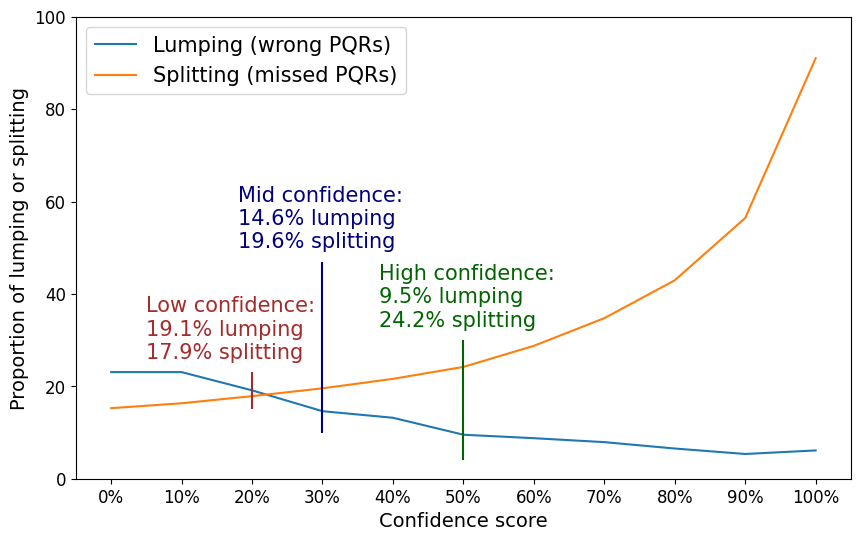

In [12]:
## for each confidence category, plot the accuracy
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'font.size': 12})


df_confidence['output0'] = [ 1 if elem[0] > 0 and elem[1] > 0 else 0 for elem in df_confidence[['matches_PV_to_GS','matches_OA_to_GS']].to_numpy() ] 
df_confidence['output3'] = [ 1 if elem[0] > 0.3 and elem[1] > 0.3 else 0 for elem in df_confidence[['matches_PV_to_GS','matches_OA_to_GS']].to_numpy() ] 

low = 2
mid =3
high = 5

Y1 = [] 
Y2 = []
for conf in range(0,11):
    Y1.append(100 - 100*df_confidence[df_confidence['conf'] >= conf]['output0'].mean())
    Y2.append(100 - 100*df_confidence[df_confidence['conf'] >= conf]['output3'].mean())

plt.figure(figsize=(10,6))
#plt.title("Accuracy of the SI dataset using Google Scholar" , fontsize=16)
#plt.errorbar([str(10*k) + "%" for k in range(1,11)], 100*df_confidence[['conf','output0']].groupby('conf').mean()['output0'],100*df_confidence[['conf','output0']].groupby('conf').sem()['output0'] )
#plt.errorbar([str(10*k) + "%" for k in range(1,11)], 100*df_confidence[['conf','output3']].groupby('conf').mean()['output3'],100*df_confidence[['conf','output3']].groupby('conf').sem()['output3']  )
plt.plot([str(10*k) + "%" for k in range(0,11)], Y1  )
plt.plot([str(10*k) + "%" for k in range(0,11)], [ 100*elem for elem in dic_FPR.values() ]  )
#plt.plot([str(10*k) + "%" for k in range(1,11)], Y2  )

#plt.plot([str(10*k) + "%" for k in range(1,11)], 100*df_confidence[['conf','output3']].groupby('conf').mean()['output3'] )

plt.vlines(2,15,23, color = 'brown')
plt.vlines(3,10,47, color = 'navy')
plt.vlines(5,4,30, color = 'darkgreen')

plt.text(0.5,26,"Low confidence:\n" + str(  round(100 - 100*df_confidence[df_confidence['conf'] >= low]['output0'].mean(),1)) + "% lumping\n" + str(100*round(dic_FPR[low/10],3)) + "% splitting", fontsize=15, color = 'brown')
plt.text(1.8,50,"Mid confidence:\n" + str( round(100 - 100*df_confidence[df_confidence['conf'] >= mid]['output0'].mean(),1)) + "% lumping\n"+ str(100*round(dic_FPR[mid/10],3)) + "% splitting", fontsize=15, color = 'navy')
plt.text(3.8,33,"High confidence:\n" + str(  round(100 - 100*df_confidence[df_confidence['conf'] >= high]['output0'].mean(),1)) + "% lumping\n"+ str(100*round(dic_FPR[high/10],3)) + "% splitting", fontsize=15, color = 'darkgreen')

plt.ylabel("Proportion of lumping or splitting", fontsize=14)
plt.xlabel("Confidence score", fontsize=14)
plt.legend([ 'Lumping (wrong PQRs)', 'Splitting (missed PQRs)'], fontsize = 15)


#plt.legend(["at least 1 paper from OA and one patent from PV in GS", "at least 30% of papers from OA and 30% of patents from PV in GS"], fontsize=12)
plt.ylim([0,100])
#plt.grid()
plt.show()

In [23]:
"Low confidence: " + str(round(100*df_confidence[df_confidence['conf'] > low]['output3'].mean(),1)) + "% TPR " + str(100*round(dic_FPR[low/10],3)) + "% FPR"


'Low confidence: 78.1% TPR 15.0% FPR'

In [24]:
"Mid confidence: " + str(round(100*df_confidence[df_confidence['conf'] > mid]['output3'].mean(),1)) + "% TPR "+ str(100*round(dic_FPR[mid/10],3)) + "% FPR"


'Mid confidence: 79.2% TPR 16.5% FPR'

In [25]:
"High confidence: " + str(round(100*df_confidence[df_confidence['conf'] > high]['output3'].mean(),1)) + "% TPR "+ str(100*round(dic_FPR[high/10],3)) + "% FPR"


'High confidence: 83.8% TPR 20.7% FPR'